In [1]:
from music21 import *

/Users/skye/.cache/uv/archive-v0/0woMiqm0BCKIsVKkpcGVe/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [87]:
score = converter.parse('../assets/fantaisie-philippe-gaubert.mxl')
score.metadata.composer = "Philippe Gaubert"
score.metadata.movementName = "Fantaisie pour flûte et piano"

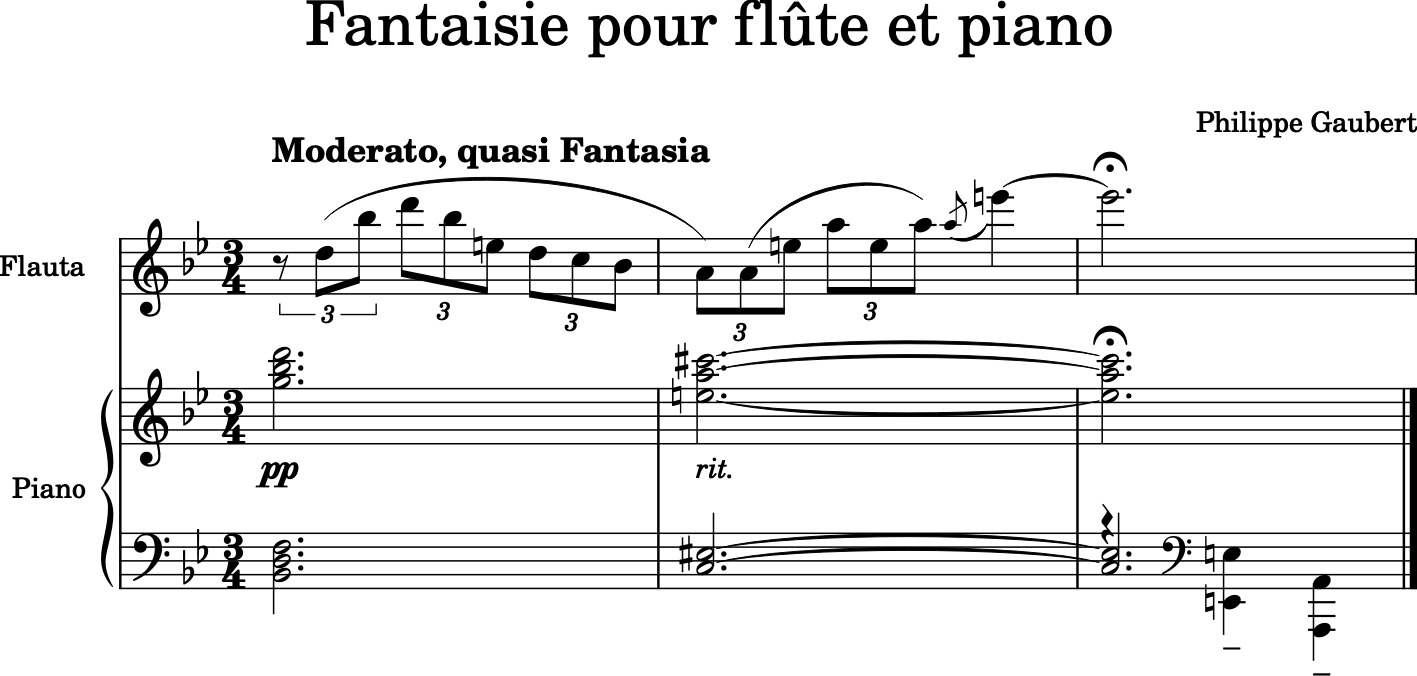

In [88]:
# Show the first three bars
score.measures(1,3).show()

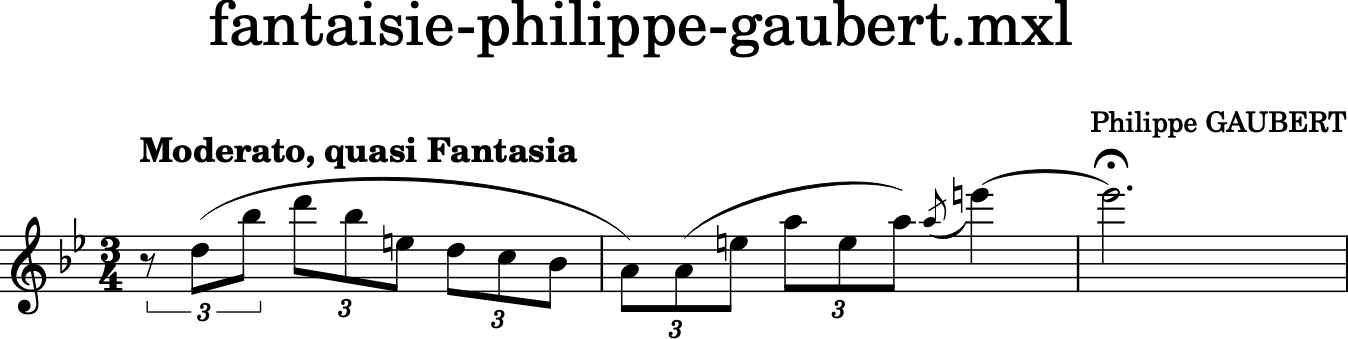

In [89]:
# Extract just the flute part and view it 
flute = d.getElementsByClass(stream.Part).first()
flute.measures(1,3).show()

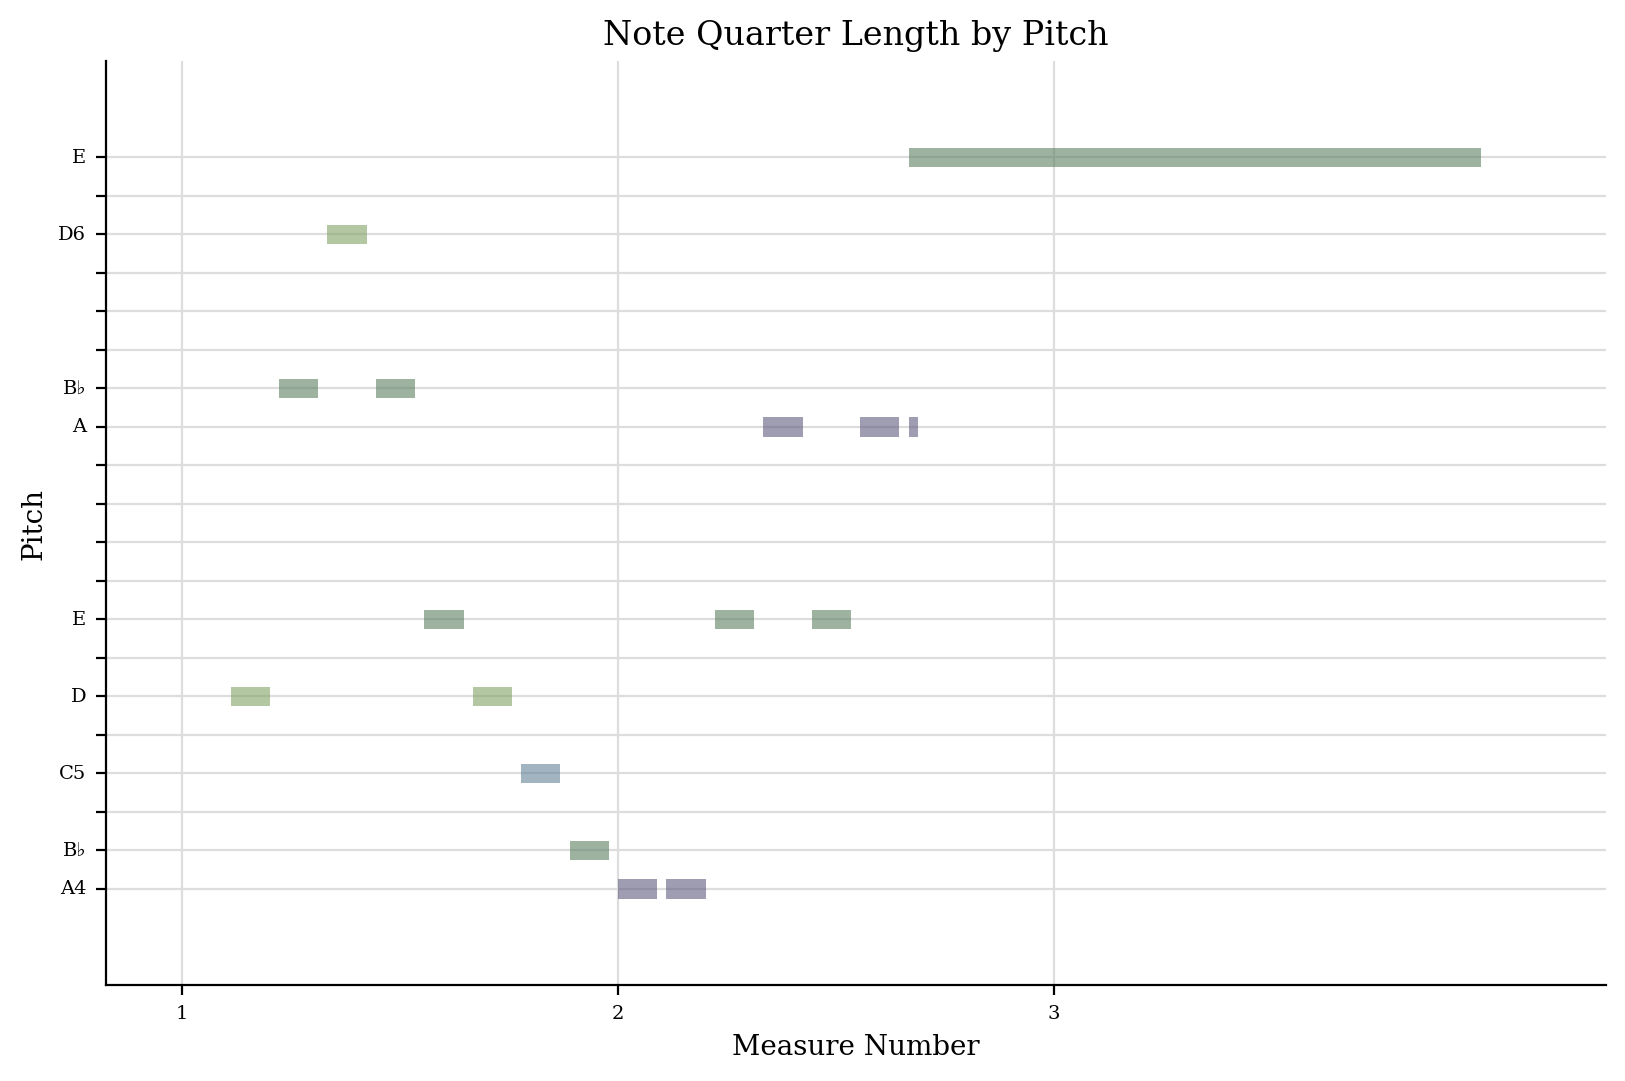

In [90]:
flute.measures(1,3).plot('pianoroll')

In [30]:
flute.measures(1,3).show('midi')

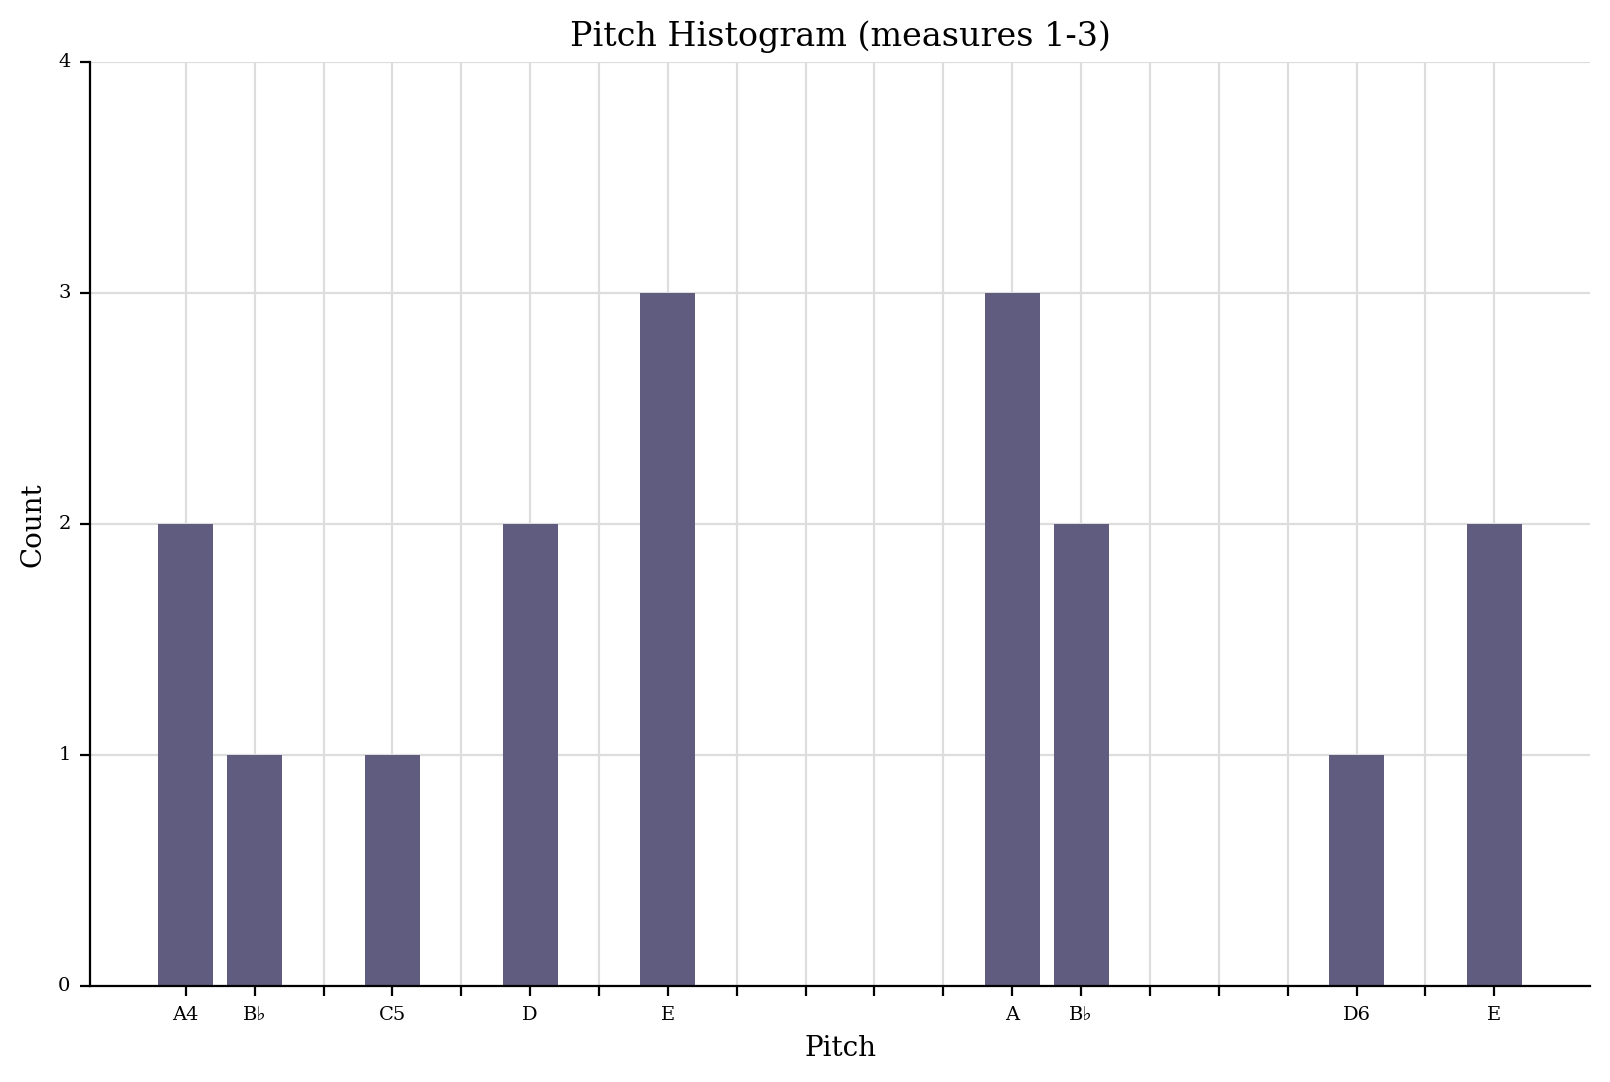

In [91]:
flute.measures(1,3).plot('histogram', 'pitch', xHideUnused=False,
                        title='Pitch Histogram (measures 1-3)')

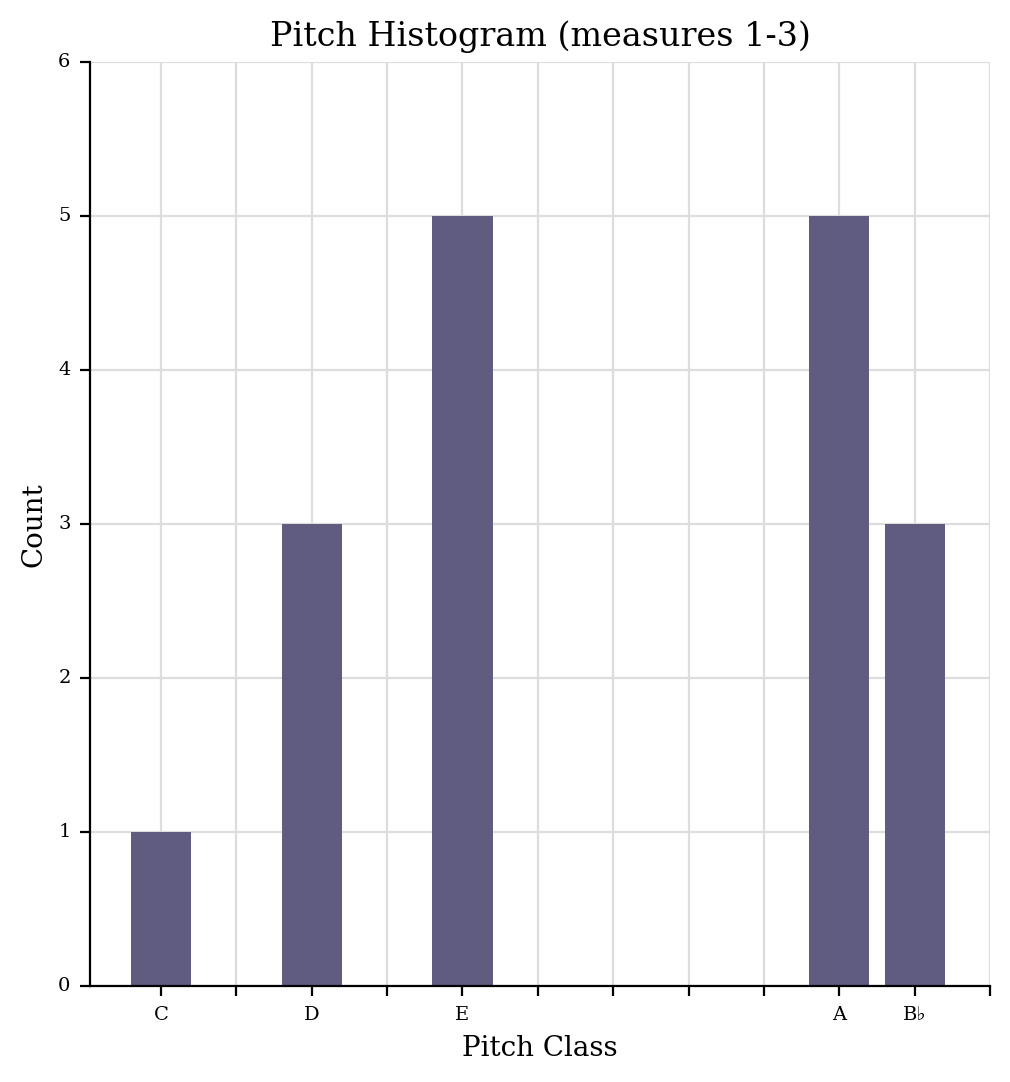

In [93]:
flute.measures(1,3).plot('histogram', 'pitchClass', xHideUnused=False,
                        title='Pitch Histogram (measures 1-3)')

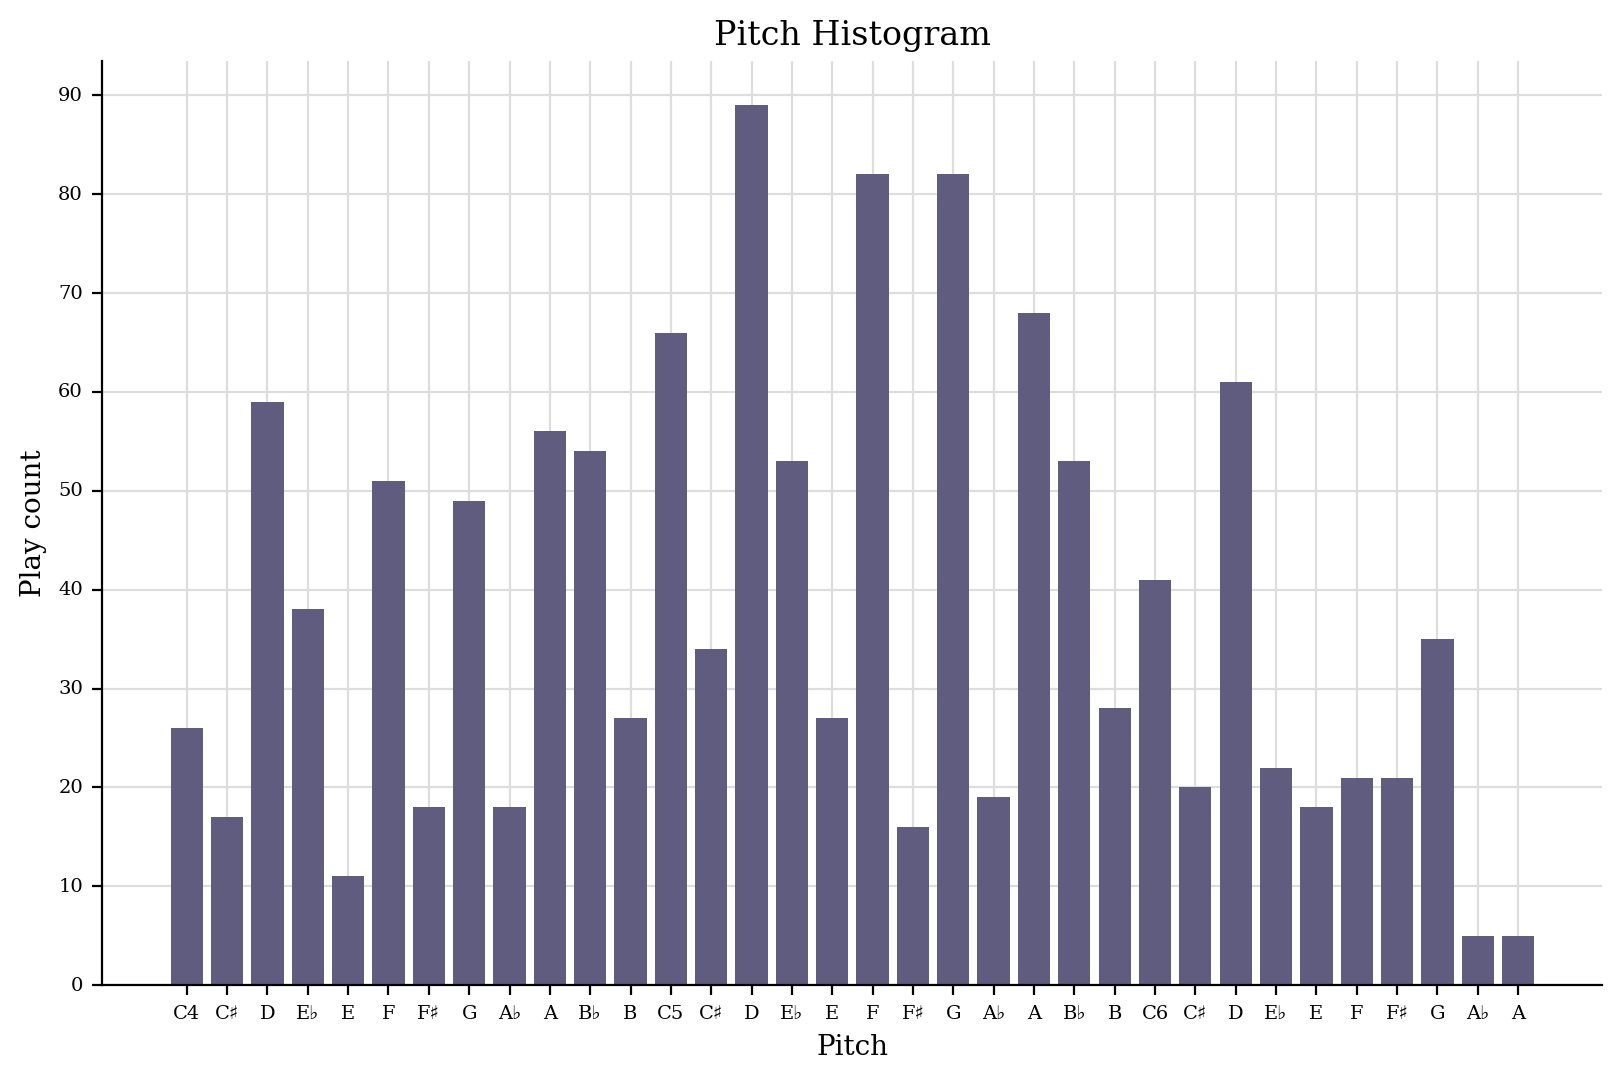

In [110]:
flute.plot('histogram', 'pitch', xHideUnused=False,
          xLabel="Pitch", yLabel="Play count")

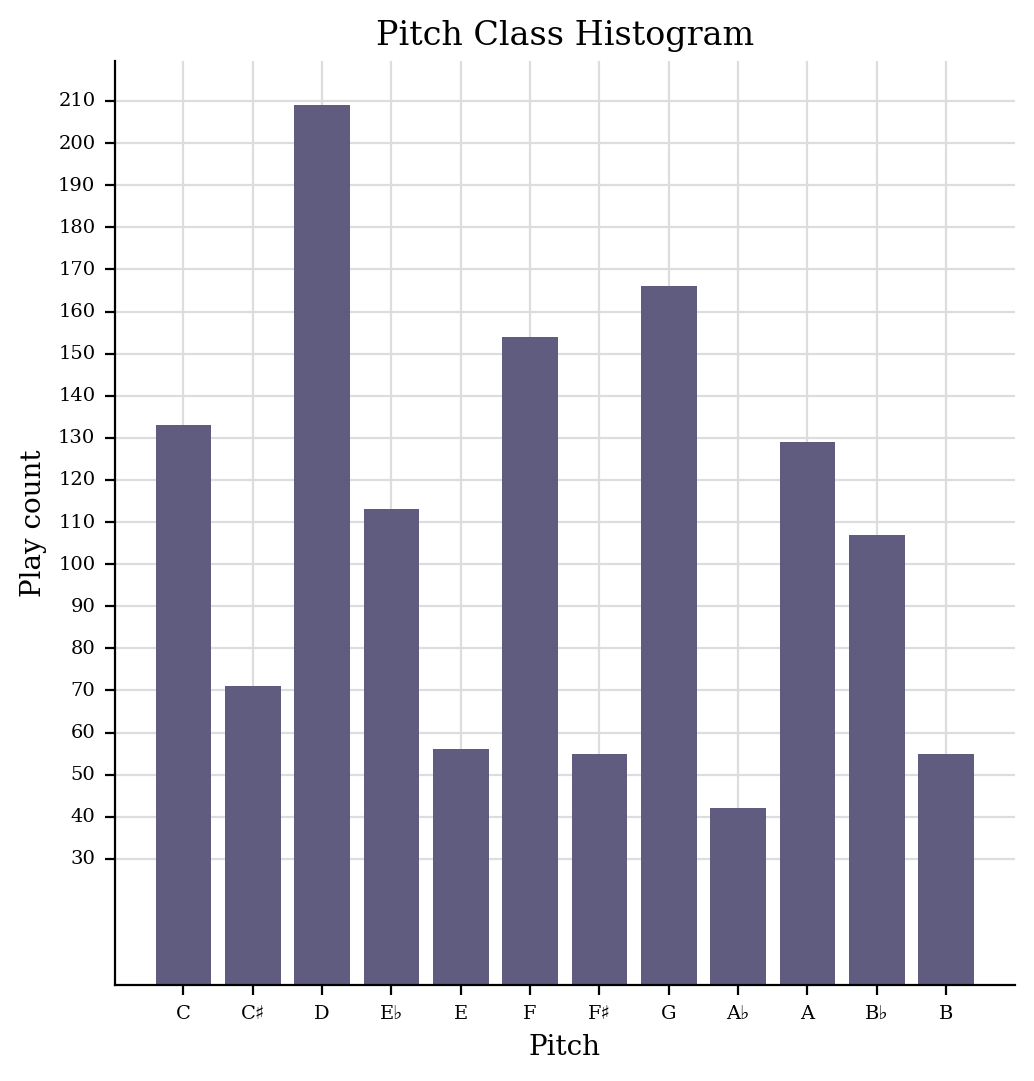

In [94]:
flute.plot('histogram', 'pitchClass', xHideUnused=False,
          xLabel="Pitch", yLabel="Play count")

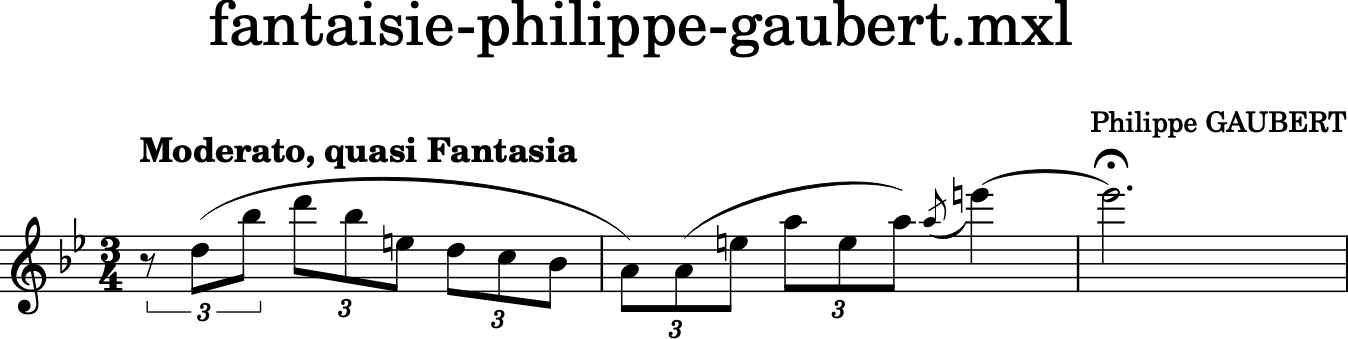

In [96]:
flute.measures(1,3).show()

In [67]:
# What's our note count?
len(flute.measures(1,3).recurse().notes)

17

In [98]:
# Huh. That doesn't match my hand count of 16. It looks like the count includes grace 
# notes (good) but double-counts ties (bad)
# Instead of counting all written notes, let's only count 
# notes that are either not part of a tie OR are the start of a tie
def count_notes_played(input):
    return len([n for n in input.recurse().notes if  not n.tie or n.tie.type == "start"])
        
count_notes_played(flute.measures(1,3))

16

In [100]:
# That's more like it! How many in the whole piece?
count_notes_played(flute)

1220

In [153]:
# By comparison, how many did the piano player play?

In [128]:
piano_rh = score.getElementsByClass(stream.Part)[1]
piano_lh = score.getElementsByClass(stream.Part)[2]

In [129]:
print("  Piano left hand: " + str(count_notes_played(piano_lh)) + 
"\n Piano right hand: " + str(count_notes_played(piano_rh)) + \
"\nPiano total notes: " + str(count_notes_played(piano_lh) + count_notes_played(piano_rh)))

  Piano left hand: 586
 Piano right hand: 490
Piano total notes: 1076


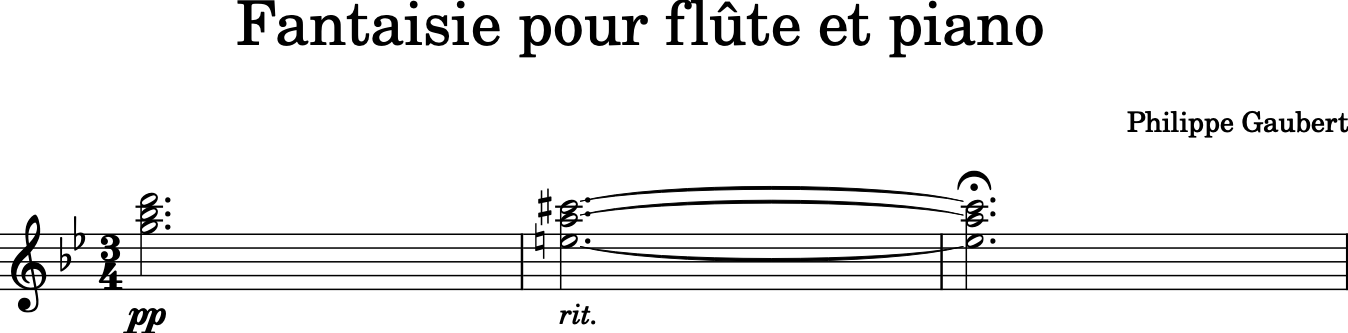

In [130]:
# Huh, really? That seems kind of low to me. Let's visualize the first few bars
piano_rh.measures(1,3).show()

In [131]:
# And what does our function say?
count_notes_played(piano_rh.measures(1,3))


2

In [132]:
# ...well THAT isn't right! :D What's going on? My hunch is that we aren't 
# counting notes, we're counting chords---but handling the chord correctly.
# Let's look at the so-called notes:

list(piano_rh.measures(1,3).recurse().notes)

[<music21.chord.Chord G5 B-5 D6>,
 <music21.chord.Chord E5 A5 C#6>,
 <music21.chord.Chord E5 A5 C#6>]

In [133]:
# Yep, that's it!

# For flutes, which are typically monophonic, number of sounds played
# and number of notes played are the same thing. 
# For pianos, which are polyphonic, even though they are changing sounds 4 times 
# they are playing many more than that number of pitches/notes.
# Let's try to count that.

In [135]:
def count_notes_played_polyphonic(input):
    total_notes = 0
    for n in input.recurse().notes:
        if n.tie and n.tie.type != "start":
            continue
        if n.isNote:
            total_notes += 1
        else:
            total_notes += len(n.pitches)
    return total_notes

count_notes_played_polyphonic(piano_rh.measures(1,3))

6

In [136]:
# That's more like it!

# And the whole piece?
print("  Piano left hand: " + str(count_notes_played_polyphonic(piano_lh)) + 
"\n Piano right hand: " + str(count_notes_played_polyphonic(piano_rh)) + \
"\nPiano total notes: " + str(count_notes_played_polyphonic(piano_lh) + count_notes_played_polyphonic(piano_rh)))

  Piano left hand: 787
 Piano right hand: 763
Piano total notes: 1550
